# 2 — Baseline Models
**Author:** Sai Srinivas Uppara

Trains and evaluates:
1. **BiLSTM + Attention** (text-only baseline)
2. **Gated Fusion** (multimodal baseline, 4 modalities)

Also loads the pretrained Gated Fusion and Cross-Attention weights from the teammate's training.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.join(os.pardir, "src"))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from config import (
    EMBEDDINGS_DIR, MODELS_DIR, RESULTS_DIR, PRETRAINED_DIR,
    TEXT_DIM, IMAGE_DIM, AUDIO_DIM, VIDEO_DIM, HIDDEN_DIM,
    NUM_CLASSES, DROPOUT, BATCH_SIZE, LEARNING_RATE, WEIGHT_DECAY,
    NUM_EPOCHS, PATIENCE, RANDOM_SEED,
)
from data_utils import load_embeddings, create_splits, make_dataloader
from models import BiLSTMTextOnly, GatedFusionModel, CrossAttentionModel
from train_utils import train_one_epoch, evaluate

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

Device: cpu


/home/katarir/Downloads/FINAL/venv/lib/python3.13/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
text, image, audio, video, labels = load_embeddings(EMBEDDINGS_DIR)
train_split, val_split, test_split = create_splits(
    text, image, audio, video, labels, seed=RANDOM_SEED
)

train_loader = make_dataloader(train_split, BATCH_SIZE, shuffle=True)
val_loader   = make_dataloader(val_split, BATCH_SIZE, shuffle=False)
test_loader  = make_dataloader(test_split, BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_split[-1]):,}  Val: {len(val_split[-1]):,}  Test: {len(test_split[-1]):,}")

[data] Loaded 43,131 samples
       text=(43131, 768) image=(43131, 1280) audio=(43131, 768) video=(43131, 768)
Train: 30,191  Val: 4,313  Test: 8,627


## Training helper

In [3]:
def train_model(model, name, epochs=NUM_EPOCHS, patience=PATIENCE):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

    history = {"train_loss": [], "val_loss": [], "val_f1": []}
    best_f1, wait = 0.0, 0
    save_path = os.path.join(MODELS_DIR, f"{name}.pt")

    for ep in range(1, epochs + 1):
        tl, ta = train_one_epoch(model, train_loader, optimizer, criterion, device)
        vl, vm, _, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(vl)
        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["val_f1"].append(vm["f1"])
        print(f"  [{name}] Ep {ep:02d}  TrL={tl:.4f}  VL={vl:.4f}  VF1={vm['f1']:.4f}")
        if vm["f1"] > best_f1:
            best_f1 = vm["f1"]
            torch.save(model.state_dict(), save_path)
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stop at {ep}")
                break

    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    _, test_met, _, _, _ = evaluate(model, test_loader, criterion, device)
    print(f"  [{name}] Test: {test_met}")

    with open(os.path.join(RESULTS_DIR, f"{name}_metrics.json"), "w") as f:
        json.dump({"test": test_met, "history": history}, f, indent=2)
    return model, test_met, history

## 2.1 BiLSTM + Attention (text-only)

In [4]:
bilstm = BiLSTMTextOnly(text_dim=TEXT_DIM, hidden=HIDDEN_DIM,
                       num_classes=NUM_CLASSES, dropout=DROPOUT)
print(f"Params: {sum(p.numel() for p in bilstm.parameters()):,}")
bilstm_model, bilstm_met, bilstm_hist = train_model(bilstm, "baseline_bilstm")

Params: 5,127,938
  [baseline_bilstm] Ep 01  TrL=0.2912  VL=0.2385  VF1=0.9042
  [baseline_bilstm] Ep 02  TrL=0.2045  VL=0.2284  VF1=0.9203
  [baseline_bilstm] Ep 03  TrL=0.1387  VL=0.2894  VF1=0.9120
  [baseline_bilstm] Ep 04  TrL=0.1017  VL=0.3537  VF1=0.9134
  [baseline_bilstm] Ep 05  TrL=0.0899  VL=0.3430  VF1=0.9124
  [baseline_bilstm] Ep 06  TrL=0.0744  VL=0.4530  VF1=0.9153
  [baseline_bilstm] Ep 07  TrL=0.0686  VL=0.4585  VF1=0.9184
  Early stop at 7
  [baseline_bilstm] Test: {'accuracy': 0.916, 'precision': 0.9157, 'recall': 0.916, 'f1': 0.9158, 'auc': 0.9558}


## 2.2 Gated Fusion (multimodal) — train from scratch

In [5]:
gf = GatedFusionModel(text_dim=TEXT_DIM, image_dim=IMAGE_DIM,
                     audio_dim=AUDIO_DIM, video_dim=VIDEO_DIM,
                     hidden=HIDDEN_DIM, num_classes=NUM_CLASSES, dropout=DROPOUT)
print(f"Params: {sum(p.numel() for p in gf.parameters()):,}")
gf_model, gf_met, gf_hist = train_model(gf, "baseline_gated_fusion")

Params: 3,019,522
  [baseline_gated_fusion] Ep 01  TrL=0.4160  VL=0.3162  VF1=0.8625
  [baseline_gated_fusion] Ep 02  TrL=0.3028  VL=0.2884  VF1=0.8740
  [baseline_gated_fusion] Ep 03  TrL=0.2819  VL=0.2739  VF1=0.8863
  [baseline_gated_fusion] Ep 04  TrL=0.2695  VL=0.2636  VF1=0.8910
  [baseline_gated_fusion] Ep 05  TrL=0.2637  VL=0.2586  VF1=0.8935
  [baseline_gated_fusion] Ep 06  TrL=0.2582  VL=0.2551  VF1=0.8956
  [baseline_gated_fusion] Ep 07  TrL=0.2538  VL=0.2532  VF1=0.8951
  [baseline_gated_fusion] Ep 08  TrL=0.2503  VL=0.2499  VF1=0.8983
  [baseline_gated_fusion] Ep 09  TrL=0.2468  VL=0.2470  VF1=0.8984
  [baseline_gated_fusion] Ep 10  TrL=0.2447  VL=0.2467  VF1=0.8994
  [baseline_gated_fusion] Ep 11  TrL=0.2415  VL=0.2442  VF1=0.8995
  [baseline_gated_fusion] Ep 12  TrL=0.2388  VL=0.2429  VF1=0.9045
  [baseline_gated_fusion] Ep 13  TrL=0.2361  VL=0.2410  VF1=0.9062
  [baseline_gated_fusion] Ep 14  TrL=0.2328  VL=0.2412  VF1=0.9049
  [baseline_gated_fusion] Ep 15  TrL=0.2301 

## 2.3 Evaluate pretrained models

These were trained by the teammate and saved as `.pth` files.

In [6]:
criterion = nn.CrossEntropyLoss()

# Pretrained Cross-Attention
ca = CrossAttentionModel(text_dim=TEXT_DIM, image_dim=IMAGE_DIM,
                         audio_dim=AUDIO_DIM, video_dim=VIDEO_DIM,
                         hidden=HIDDEN_DIM).to(device)
ca.load_state_dict(torch.load(
    os.path.join(PRETRAINED_DIR, "cross_attention_model.pth"),
    map_location=device, weights_only=True))
_, ca_met, _, _, _ = evaluate(ca, test_loader, criterion, device)
print(f"Pretrained Cross-Attention: {ca_met}")

with open(os.path.join(RESULTS_DIR, "pretrained_cross_attention_metrics.json"), "w") as f:
    json.dump({"test": ca_met}, f, indent=2)

# Pretrained Gated Fusion
gf_pre = GatedFusionModel(text_dim=TEXT_DIM, image_dim=IMAGE_DIM,
                          audio_dim=AUDIO_DIM, video_dim=VIDEO_DIM,
                          hidden=HIDDEN_DIM).to(device)
gf_pre.load_state_dict(torch.load(
    os.path.join(PRETRAINED_DIR, "gated_fusion_model.pth"),
    map_location=device, weights_only=True))
_, gf_pre_met, _, _, _ = evaluate(gf_pre, test_loader, criterion, device)
print(f"Pretrained Gated Fusion:    {gf_pre_met}")

with open(os.path.join(RESULTS_DIR, "pretrained_gated_fusion_metrics.json"), "w") as f:
    json.dump({"test": gf_pre_met}, f, indent=2)

Pretrained Cross-Attention: {'accuracy': 0.9027, 'precision': 0.903, 'recall': 0.9027, 'f1': 0.9029, 'auc': 0.9407}
Pretrained Gated Fusion:    {'accuracy': 0.8914, 'precision': 0.8995, 'recall': 0.8914, 'f1': 0.8935, 'auc': 0.9459}


## 2.4 Baseline comparison

                              accuracy  precision  recall      f1     auc
Model                                                                    
BiLSTM (text-only)              0.9160     0.9157  0.9160  0.9158  0.9558
Gated Fusion (trained)          0.9043     0.9035  0.9043  0.9038  0.9462
Cross-Attention (pretrained)    0.9027     0.9030  0.9027  0.9029  0.9407
Gated Fusion (pretrained)       0.8914     0.8995  0.8914  0.8935  0.9459


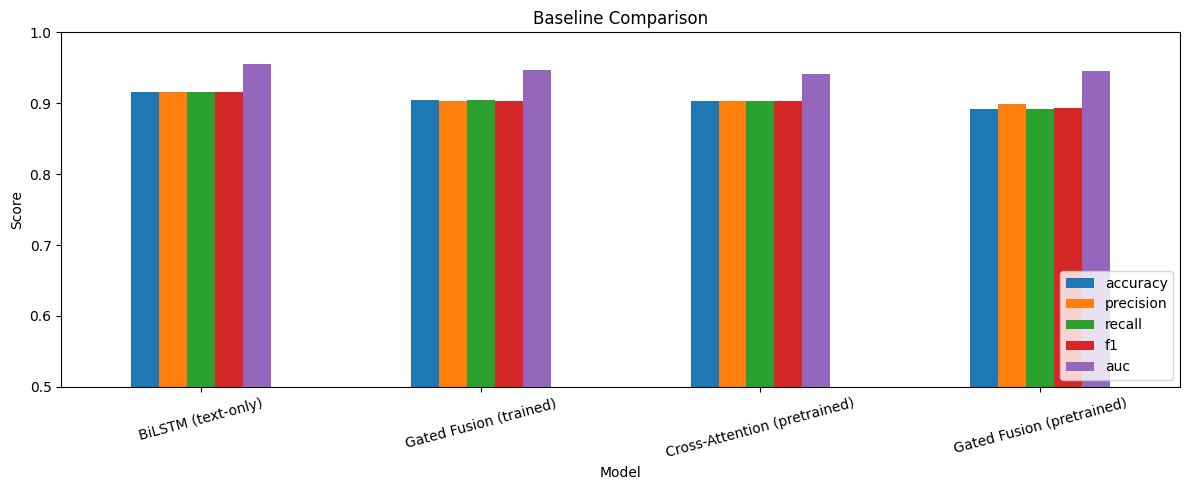

In [7]:
import pandas as pd

rows = [
    {"Model": "BiLSTM (text-only)", **bilstm_met},
    {"Model": "Gated Fusion (trained)", **gf_met},
    {"Model": "Cross-Attention (pretrained)", **ca_met},
    {"Model": "Gated Fusion (pretrained)", **gf_pre_met},
]
df = pd.DataFrame(rows).set_index("Model")
print(df.to_string())

df.plot(kind="bar", figsize=(12, 5), ylim=(0.5, 1.0), rot=15)
plt.title("Baseline Comparison")
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()